<h1 style="text-align:center;">Digital Transformation Leaders Analysis</h1>

<p style>
This project explores activity patterns in a large-scale digital transaction system. 
The dataset represents transactional and operational events generated by users interacting with a digital platform, 
such as a financial technology system, payment infrastructure, or online service.The goal of the analysis is to understand behavioral and operational patterns within the system by examining transaction volumes, event distributions, and client activity. Such analyses are commonly used by organizations undergoing digital transformation to better understand system usage, monitor operational performance, and identify opportunities for process optimization. 

The analysis focuses on exploratory data analysis (EDA) using Python, with the objective of uncovering patterns in transaction behavior and system events.

</p>

## Analytical Questions

The exploratory analysis focuses on several key questions related to system activity and transaction behavior:

• How are transaction amounts distributed across the system?

• Are there observable temporal patterns in transaction activity?

• Which clients generate the highest number of events?

• What types of events occur most frequently within the system?

• Are there relationships between numerical attributes describing transactions and system events?

Answering these questions helps reveal behavioral and operational patterns within the digital transaction system.

<hr>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

## Data Loading

The dataset is stored in parquet format and contains records of transactional events generated within a digital system. Each row represents a single event associated with a client interaction, including the timestamp of the event, transaction amount, and various attributes describing the type and context of the event.

Loading the dataset allows us to begin exploring its structure and preparing the data for analysis.

In [ ]:
df = pd.read_parquet("data/trx_train.parquet")

df.head()


,event_time,amount,client_id,event_type,event_subtype,currency,src_type11,src_type12,dst_type11,dst_type12,src_type21,src_type22,src_type31,src_type32
0,2022-04-29 13:56:58.137690,156129.734375,51f88b707d9c8766cdbdfe799ba0fafd8f5b8034b08c46...,56,9,11.0,109.0,74.0,364.0,22652.0,46339.0,43.0,2423.0,25.0
1,2022-07-19 12:28:12.873540,357370.218750,51f88b707d9c8766cdbdfe799ba0fafd8f5b8034b08c46...,56,9,11.0,109.0,74.0,364.0,22652.0,46339.0,43.0,2423.0,25.0
2,2022-11-20 10:20:30.740937,93367.710938,51f88b707d9c8766cdbdfe799ba0fafd8f5b8034b08c46...,56,9,11.0,109.0,74.0,364.0,22652.0,46339.0,43.0,2423.0,25.0
3,2022-02-15 23:16:13.024817,3449.269531,522256f58adeaf13fbf098859fe5627f663ab586cb71e7...,40,51,11.0,72.0,189.0,433.0,10049.0,29715.0,10.0,814.0,26.0
4,2022-10-11 04:17:05.703176,365.863831,522256f58adeaf13fbf098859fe5627f663ab586cb71e7...,40,51,11.0,72.0,189.0,433.0,10049.0,29715.0,10.0,814.0,26.0


## Dataset Overview

In this section we explore the basic structure of the dataset. This includes the number of observations, available variables, and data types for each column.
Understanding the dataset structure is an important first step in any analytical workflow, as it helps identify which variables can be used for further analysis and visualization.

In [5]:
df.shape

(167467698, 14)

In [6]:
df.columns

Index(['event_time', 'amount', 'client_id', 'event_type', 'event_subtype',
       'currency', 'src_type11', 'src_type12', 'dst_type11', 'dst_type12',
       'src_type21', 'src_type22', 'src_type31', 'src_type32'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167467698 entries, 0 to 167467697
Data columns (total 14 columns):
 #   Column         Dtype         
---  ------         -----         
 0   event_time     datetime64[us]
 1   amount         float32       
 2   client_id      str           
 3   event_type     int32         
 4   event_subtype  int32         
 5   currency       float64       
 6   src_type11     float64       
 7   src_type12     float64       
 8   dst_type11     float64       
 9   dst_type12     float64       
 10  src_type21     float64       
 11  src_type22     float64       
 12  src_type31     float64       
 13  src_type32     float64       
dtypes: datetime64[us](1), float32(1), float64(9), int32(2), str(1)
memory usage: 25.6 GB


## Summary Statistics

To better understand the numerical variables in the dataset, we examine basic statistical properties such as mean, minimum, maximum, and standard deviation.

These statistics provide insight into the distribution of transaction values and other numerical attributes present in the dataset.

In [8]:
df.describe()

,event_time,amount,event_type,event_subtype,currency,src_type11,src_type12,dst_type11,dst_type12,src_type21,src_type22,src_type31,src_type32
count,167467698,1.674677e+08,1.674677e+08,1.674677e+08,1.674674e+08,1.663861e+08,1.663861e+08,1.662677e+08,1.662677e+08,1.673348e+08,1.673348e+08,1.672035e+08,1.672035e+08
mean,2022-06-22 11:27:29.062484,8.280121e+05,4.423947e+01,4.128380e+01,1.099738e+01,4.224545e+01,4.408917e+02,6.884532e+02,2.037327e+04,2.417218e+04,5.208203e+01,1.263019e+03,4.561238e+01
min,2021-12-31 21:00:00.210961,2.170887e-07,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.100000e+01,4.400000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,2022-03-31 06:32:38.588806,2.242300e+03,3.700000e+01,2.900000e+01,1.100000e+01,1.900000e+01,3.440000e+02,3.640000e+02,1.734000e+04,1.199100e+04,3.500000e+01,6.000000e+02,2.100000e+01
50%,2022-06-24 06:55:25.781647,1.649257e+04,5.100000e+01,4.900000e+01,1.100000e+01,1.900000e+01,3.440000e+02,8.130000e+02,2.265200e+04,2.571400e+04,5.600000e+01,1.318000e+03,4.400000e+01
75%,2022-09-14 11:22:09.378527,8.915577e+04,5.400000e+01,5.500000e+01,1.100000e+01,1.900000e+01,3.440000e+02,8.690000e+02,2.265200e+04,3.570100e+04,7.000000e+01,1.835000e+03,7.600000e+01
max,2022-12-20 22:59:53.424424,2.487277e+12,5.600000e+01,6.100000e+01,1.800000e+01,1.800000e+02,1.103000e+03,1.709000e+03,3.177100e+04,4.815500e+04,8.800000e+01,2.496000e+03,8.900000e+01
std,NaN,2.339732e+08,1.188236e+01,1.663355e+01,1.832326e-01,4.670575e+01,2.392461e+02,3.139070e+02,6.985825e+03,1.387824e+04,2.273562e+01,7.222539e+02,2.802225e+01


## Missing Values

Before performing deeper analysis, it is important to check whether the dataset contains missing values.

Missing data can affect the reliability of analytical results and may require cleaning or preprocessing steps depending on the level of incompleteness.

In [9]:
df.isnull().sum()

event_time             0
amount                 0
client_id              0
event_type             0
event_subtype          0
currency             267
src_type11       1081549
src_type12       1081549
dst_type11       1200032
dst_type12       1200032
src_type21        132880
src_type22        132880
src_type31        264184
src_type32        264184
dtype: int64

## Time Processing

The event_time column contains timestamps describing when each event occurred. 
To enable time-based analysis, the timestamp is converted into a datetime format and additional features such as year, month, and day are extracted.

This allows us to analyze how transaction activity changes over time.

In [16]:
df["event_time"] = pd.to_datetime(df["event_time"])

df["year"] = df["event_time"].dt.year
df["month"] = df["event_time"].dt.month
df["day"] = df["event_time"].dt.day

df[["event_time","year","month","day"]].head()

,event_time,year,month,day
0,2022-04-29 13:56:58.137690,2022,4,29
1,2022-07-19 12:28:12.873540,2022,7,19
2,2022-11-20 10:20:30.740937,2022,11,20
3,2022-02-15 23:16:13.024817,2022,2,15
4,2022-10-11 04:17:05.703176,2022,10,11


## Transaction Amount Distribution

This section examines how transaction values are distributed across the dataset.

Understanding the distribution of transaction amounts helps identify whether most transactions are small or large, and whether extreme values (outliers) exist in the data.

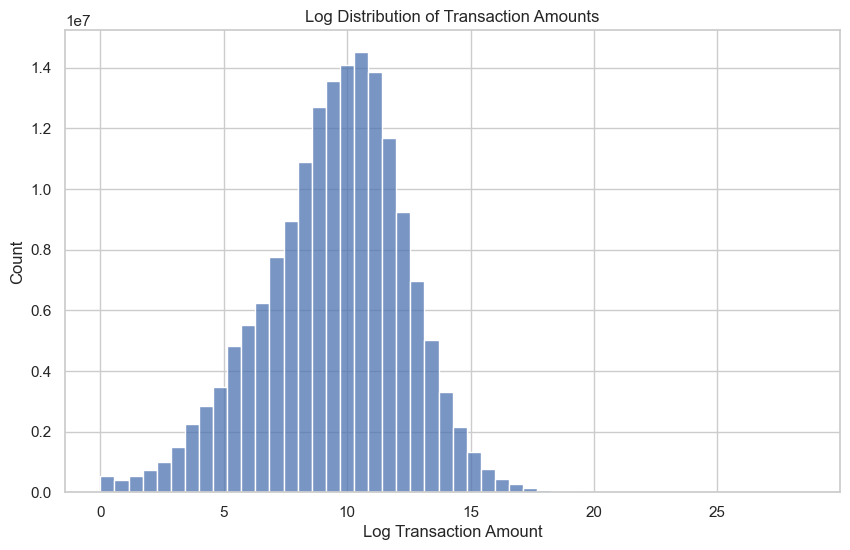

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df["amount"]), bins=50)

plt.title("Log Distribution of Transaction Amounts")
plt.xlabel("Log Transaction Amount")
plt.show()

### Interpretation

The transaction amount distribution is highly skewed, indicating that the majority of transactions are relatively small while a small number of transactions reach extremely high values. Such distributions are common in financial systems where a few large transactions coexist with a large number of smaller ones.

## Transactions Over Time

Transaction activity is analyzed across different months to identify potential temporal patterns.

Time-based analysis helps reveal whether activity levels fluctuate during the year and whether certain periods show higher levels of system usage.

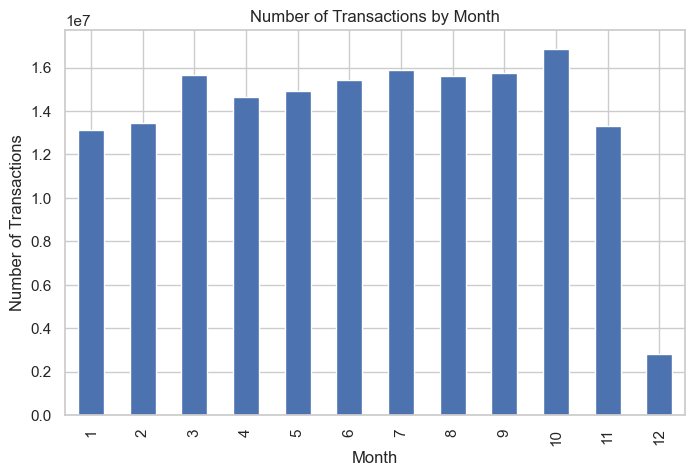

In [13]:
transactions_by_month = df.groupby("month")["amount"].count()

plt.figure(figsize=(8,5))
transactions_by_month.plot(kind="bar")

plt.title("Number of Transactions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.show()

### Interpretation

Transaction activity remains relatively stable across most months, suggesting consistent usage of the system throughout the year. However, slight fluctuations can be observed, which may indicate seasonal variations or operational changes in system usage.

## Most Active Clients

This analysis identifies clients with the highest number of recorded events. Understanding which clients generate the most activity can help identify heavy users of the system and reveal potential concentration of system usage among specific users.

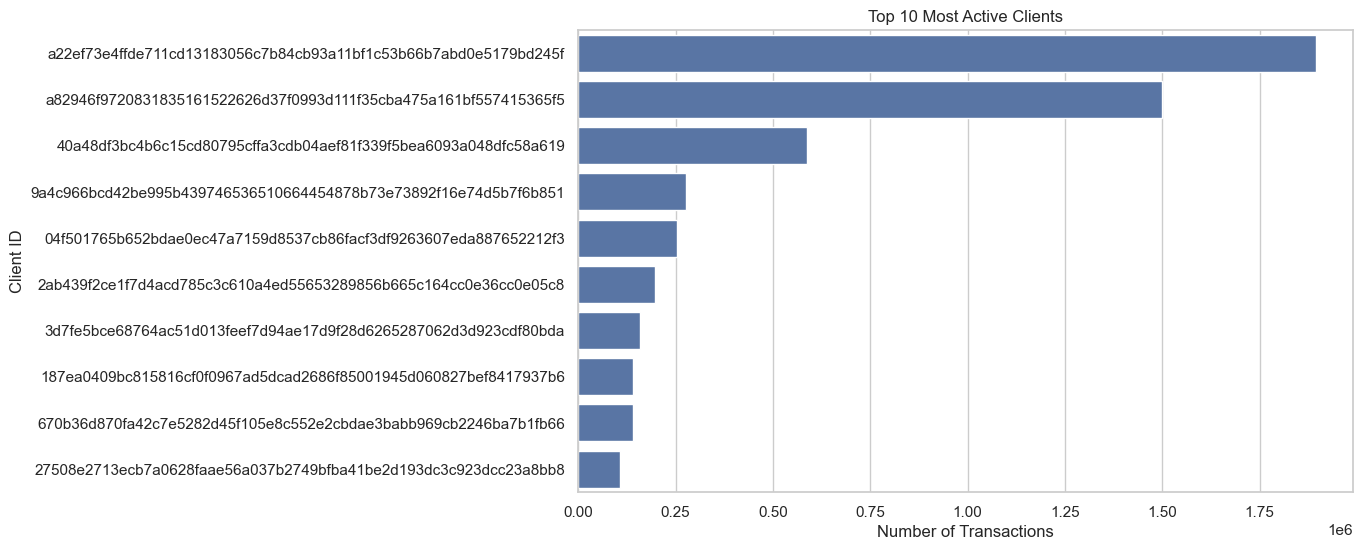

In [19]:
top_clients = df["client_id"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_clients.values, y=top_clients.index)

plt.title("Top 10 Most Active Clients")
plt.xlabel("Number of Transactions")
plt.ylabel("Client ID")

plt.show()

### Interpretation

The distribution of transactions across clients is highly uneven. A small number of clients generate a disproportionately large number of system events. This pattern is typical in digital platforms where a subset of highly active users contributes significantly to overall system activity.

## Event Type Distribution

Different event types represent various types of system interactions. Analyzing the distribution of event types provides insight into how users interact with the digital system and which operations occur most frequently.

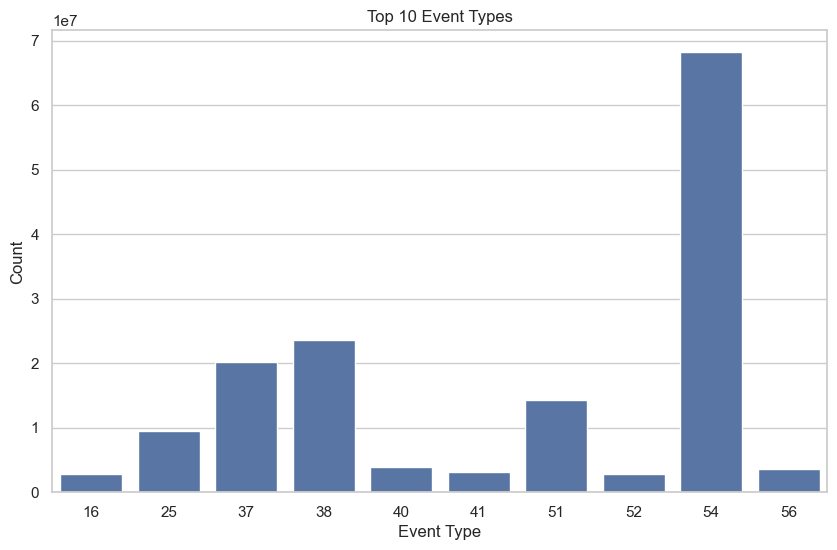

In [20]:
top_events = df["event_type"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_events.index, y=top_events.values)

plt.title("Top 10 Event Types")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

### Interpretation

Certain event types appear significantly more frequently than others, indicating that specific operations dominate system activity. This insight can help identify the most common interaction patterns within the platform.

## Feature Correlation

To better understand relationships between variables in the dataset, a correlation matrix was calculated for numerical features. Correlation analysis helps identify whether certain variables tend to increase or decrease together.

Correlation values range from -1 to 1:

- **1** indicates a strong positive relationship (variables increase together)
- **0** indicates no relationship
- **-1** indicates a strong negative relationship (one variable increases while the other decreases)

Visualizing correlations using a heatmap allows us to quickly identify potential dependencies between variables and detect patterns in system behavior.

Understanding these relationships can be useful when analyzing system dynamics, identifying related operational attributes, and detecting redundant variables in the dataset.

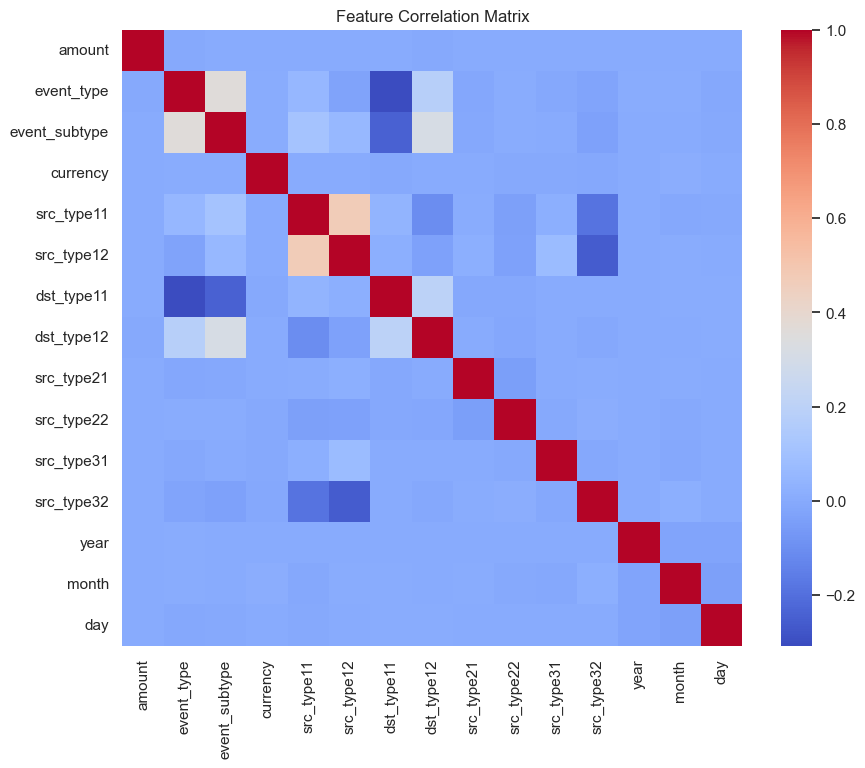

In [22]:
numeric_df = df.select_dtypes(include=['float64','float32','int32'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

### Interpretation of the Correlation Matrix

The correlation matrix shows that most variables in the dataset have relatively low correlations with each other. This suggests that the majority of features represent different aspects of the system's behavior rather than strongly overlapping information.

Some moderate relationships can be observed between certain source and destination transaction attributes (e.g., `src_type` and `dst_type` variables), which is expected as they describe related characteristics of transaction flows.

The transaction amount (`amount`) does not show strong correlations with other variables, indicating that transaction value behaves independently from most categorical system attributes.

Overall, the low correlation structure suggests that the dataset captures multiple independent dimensions of digital system activity.

<hr>

## Key Insights

The exploratory analysis reveals several interesting patterns in the dataset:

• Transaction values are highly skewed, indicating that most transactions are relatively small while a small number of transactions reach extremely large values.

• A limited number of clients generate a significant portion of total events, suggesting uneven activity distribution across users.

• Transaction activity remains relatively consistent across most months with moderate fluctuations.

• Certain event types dominate the dataset, indicating that some operations occur significantly more frequently than others.

These findings illustrate how exploratory data analysis can uncover patterns in digital transaction systems and support data-driven decision making in digital environments.

<hr>

## Business Interpretation

The findings from the exploratory analysis illustrate how transaction log data can provide insights into system usage and operational behavior.

Understanding patterns in transaction activity can support several business objectives:

• monitoring system usage and operational load

• identifying highly active users or clients

• detecting unusual transaction behavior

• optimizing digital processes and infrastructure

Such analyses are commonly used in digital transformation initiatives to improve operational transparency and enable data-driven decision making.

<hr>

## Limitations

While the dataset provides valuable insights into transaction activity, it has several limitations. The dataset does not contain contextual information about the organizations, products, or specific services generating these events. As a result, the analysis focuses primarily on behavioral patterns rather than detailed business processes. Future analyses could benefit from additional contextual variables such as user segments, product types, or geographic information.